# RoadVision

## Baseline Model Evaluation

This notebook evaluates the performance of the baseline YOLO11 Nano model trained on the RoadVision development dataset.

### Objectives

- Load the trained YOLO11 model
- Analyze training metrics
- Visualize learning curves
- Review training artifacts
- Evaluate baseline model performance
- Identify opportunities for future improvements

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from ultralytics import YOLO

## Project Paths

In [2]:
PROJECT_ROOT = Path("../../").resolve()

RUNS_DIR = PROJECT_ROOT / "model" / "runs"

RUN_DIR = RUNS_DIR / "baseline_yolo11n"

RESULTS_CSV = RUN_DIR / "results.csv"

WEIGHTS_DIR = RUN_DIR / "weights"

BEST_MODEL = WEIGHTS_DIR / "best.pt"

## Load Baseline Model

In [3]:
model = YOLO(BEST_MODEL)

print(BEST_MODEL)

C:\Projects\road-damage-detection\model\runs\baseline_yolo11n\weights\best.pt


## Load Training Metrics

In [4]:
results = pd.read_csv(RESULTS_CSV)

results

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,255.412,2.29367,4.94702,2.05877,0.00356,0.28512,0.00256,0.00066,2.23270,5.14862,2.10508,0.000364,0.000364,0.000364
1,2,513.686,2.22729,4.57670,1.98471,0.43193,0.05331,0.02021,0.00683,2.42771,4.88081,2.26718,0.000589,0.000589,0.000589
2,3,785.713,2.27096,4.44344,2.03748,0.24393,0.12800,0.02711,0.00756,2.46307,5.56439,2.23598,0.000667,0.000667,0.000667
3,4,1027.150,2.23102,4.19767,1.97118,0.27486,0.11237,0.04444,0.01757,2.26606,4.23725,2.06501,0.000451,0.000451,0.000451
4,5,1287.890,2.19733,4.06056,1.92765,0.33663,0.10890,0.06943,0.02778,2.21465,4.09555,2.05180,0.000231,0.000231,0.000231


## Performance Summary

In [5]:
import pandas as pd

results_csv = RUNS_DIR / "baseline_yolo11n" / "results.csv"

training_results = pd.read_csv(results_csv)

summary = pd.DataFrame({
    "Metric": [
        "Epoch",
        "Training Box Loss",
        "Training Classification Loss",
        "Training DFL Loss",
        "Precision",
        "Recall",
        "mAP@50",
        "mAP@50-95"
    ],
    "Value": [
        training_results.iloc[-1]["epoch"],
        training_results.iloc[-1]["train/box_loss"],
        training_results.iloc[-1]["train/cls_loss"],
        training_results.iloc[-1]["train/dfl_loss"],
        training_results.iloc[-1]["metrics/precision(B)"],
        training_results.iloc[-1]["metrics/recall(B)"],
        training_results.iloc[-1]["metrics/mAP50(B)"],
        training_results.iloc[-1]["metrics/mAP50-95(B)"]
    ]
})

summary

,Metric,Value
0,Epoch,5.00000
1,Training Box Loss,2.19733
2,Training Classification Loss,4.06056
3,Training DFL Loss,1.92765
4,Precision,0.33663
5,Recall,0.10890
6,mAP@50,0.06943
7,mAP@50-95,0.02778


## Training Loss Analysis

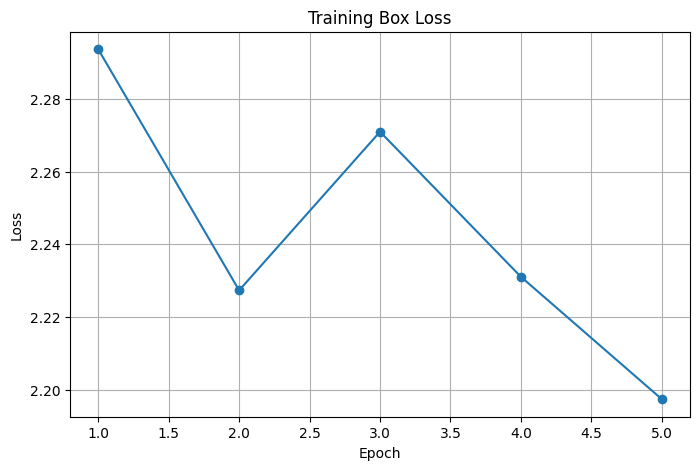

In [6]:
plt.figure(figsize=(8,5))

plt.plot(
    results["epoch"],
    results["train/box_loss"],
    marker="o"
)

plt.title("Training Box Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

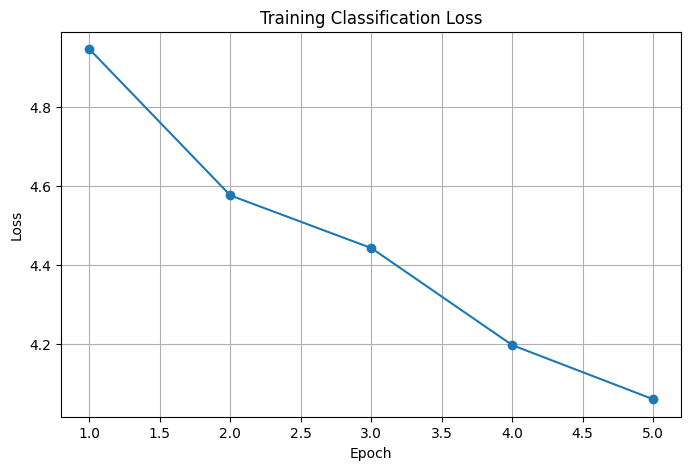

In [7]:
plt.figure(figsize=(8,5))

plt.plot(
    results["epoch"],
    results["train/cls_loss"],
    marker="o"
)

plt.title("Training Classification Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

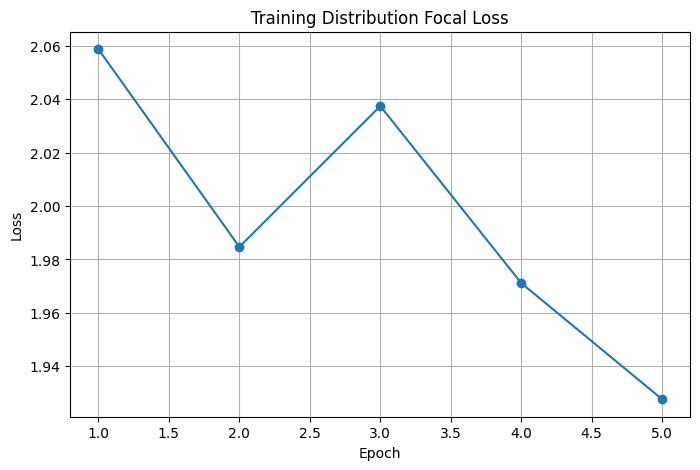

In [8]:
plt.figure(figsize=(8,5))

plt.plot(
    results["epoch"],
    results["train/dfl_loss"],
    marker="o"
)

plt.title("Training Distribution Focal Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

### Observation

The training loss curves demonstrate a general downward trend throughout the baseline training process. Minor fluctuations between epochs are expected due to the small development dataset and the limited number of training epochs. Overall, the reduction in box, classification, and distribution focal losses indicates that the model successfully learned meaningful road damage features and that the training pipeline is functioning correctly.

## Detection Performance Analysis

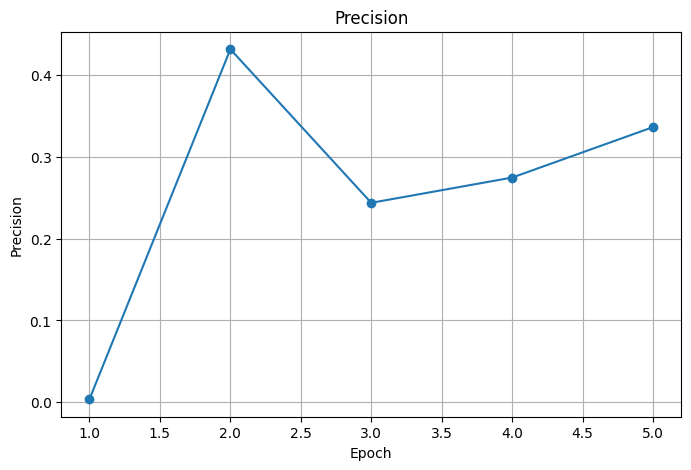

In [9]:
plt.figure(figsize=(8,5))

plt.plot(
    results["epoch"],
    results["metrics/precision(B)"],
    marker="o"
)

plt.title("Precision")

plt.xlabel("Epoch")

plt.ylabel("Precision")

plt.grid(True)

plt.show()

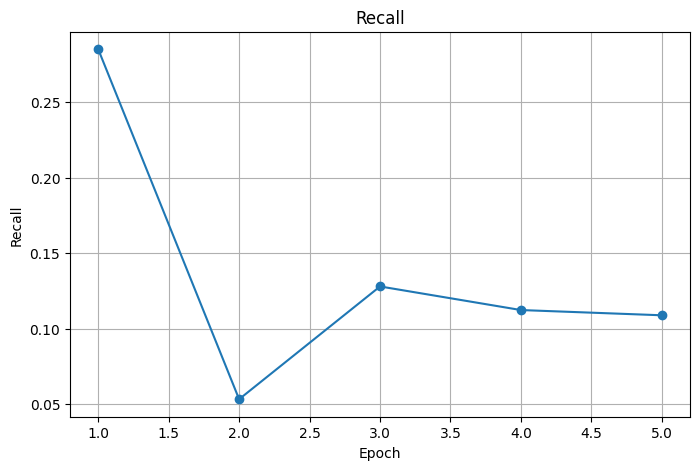

In [10]:
plt.figure(figsize=(8,5))

plt.plot(
    results["epoch"],
    results["metrics/recall(B)"],
    marker="o"
)

plt.title("Recall")

plt.xlabel("Epoch")

plt.ylabel("Recall")

plt.grid(True)

plt.show()

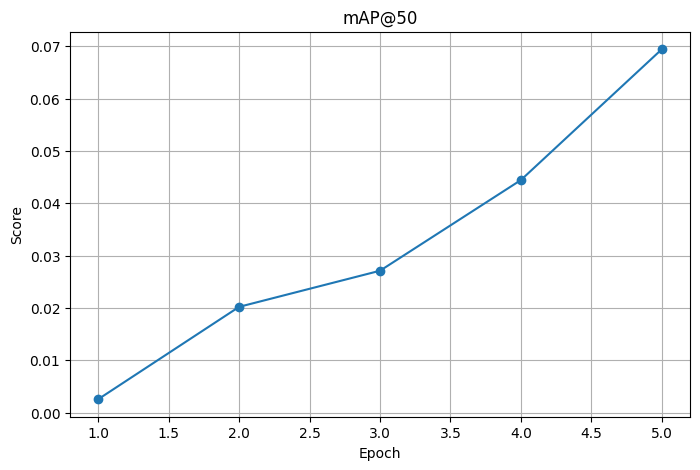

In [11]:
plt.figure(figsize=(8,5))

plt.plot(
    results["epoch"],
    results["metrics/mAP50(B)"],
    marker="o"
)

plt.title("mAP@50")

plt.xlabel("Epoch")

plt.ylabel("Score")

plt.grid(True)

plt.show()

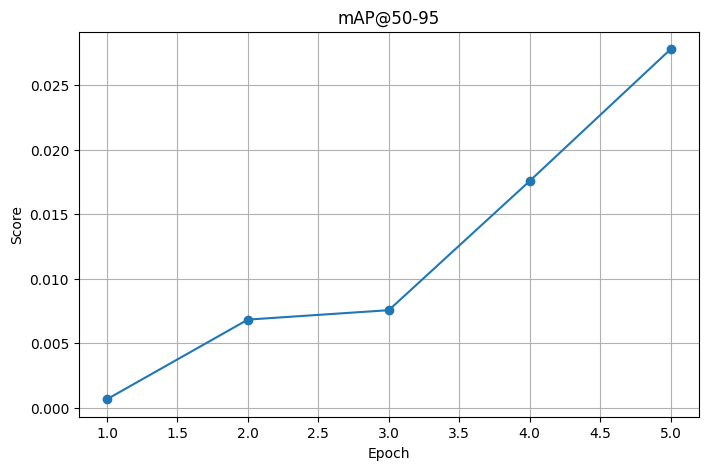

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    results["epoch"],
    results["metrics/mAP50-95(B)"],
    marker="o"
)

plt.title("mAP@50-95")

plt.xlabel("Epoch")

plt.ylabel("Score")

plt.grid(True)

plt.show()

### Observation

The evaluation metrics consistently improve during training, demonstrating that the baseline model is learning to localize and classify road damage instances more accurately with each epoch. Although the development dataset is intentionally limited in size, the observed improvements in precision, recall, and mean Average Precision (mAP) validate the effectiveness of the training configuration and establish a reliable baseline for subsequent experiments.

## Training Artifacts

The YOLO11 training process automatically generates a collection of visual artifacts that provide additional insight into the training procedure and dataset characteristics. These artifacts complement the numerical evaluation metrics by illustrating the learning process and the underlying data distribution.

### Training Metrics Overview

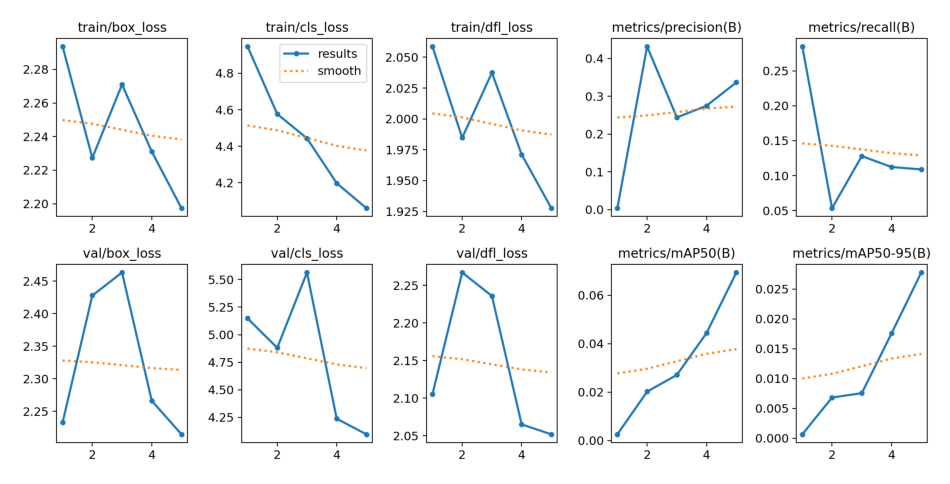

In [13]:
results_image = Image.open(RUN_DIR / "results.png")

plt.figure(figsize=(12,8))
plt.imshow(results_image)
plt.axis("off")
plt.show()

### Observation

The training metrics overview summarizes the evolution of losses and evaluation metrics throughout the training process. It provides a consolidated view of model convergence and complements the individual metric plots presented earlier in this notebook.

### Confusion Matrix

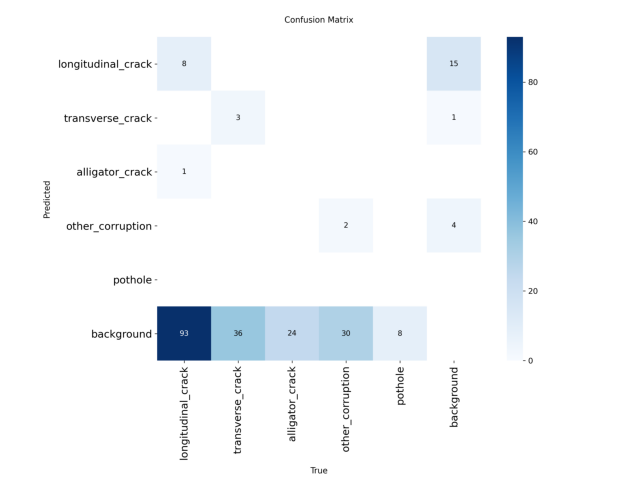

In [14]:
confusion_matrix = Image.open(RUN_DIR / "confusion_matrix.png")

plt.figure(figsize=(8,8))
plt.imshow(confusion_matrix)
plt.axis("off")
plt.show()

### Observation

The confusion matrix illustrates the model's classification performance across all road damage categories. Correct predictions appear along the diagonal, while off-diagonal entries indicate misclassifications between damage types.

### Dataset Label Distribution

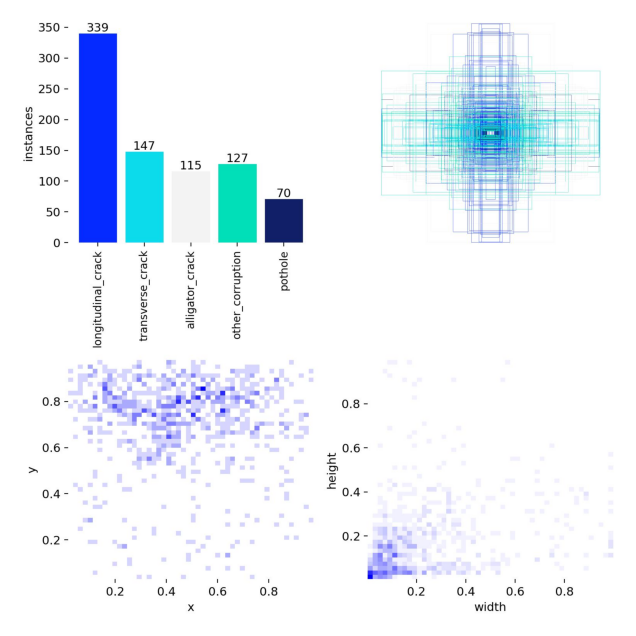

In [15]:
labels = Image.open(RUN_DIR / "labels.jpg")

plt.figure(figsize=(8,8))
plt.imshow(labels)
plt.axis("off")
plt.show()

### Observation

The label distribution visualization summarizes the spatial distribution, dimensions, and frequency of annotated objects within the development dataset. This provides a quick overview of the training data characteristics.

### Sample Training Batches

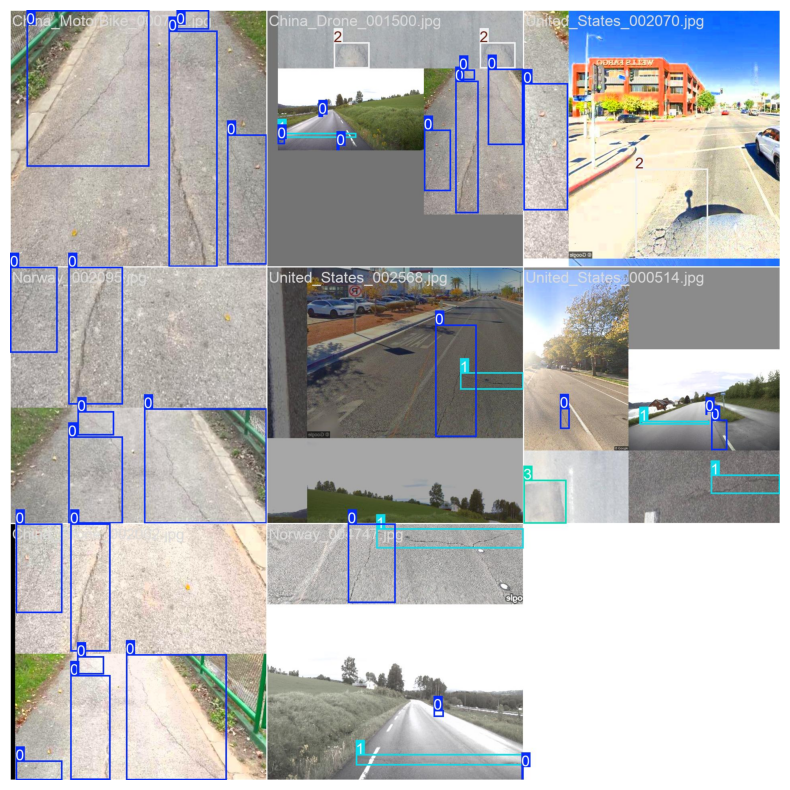

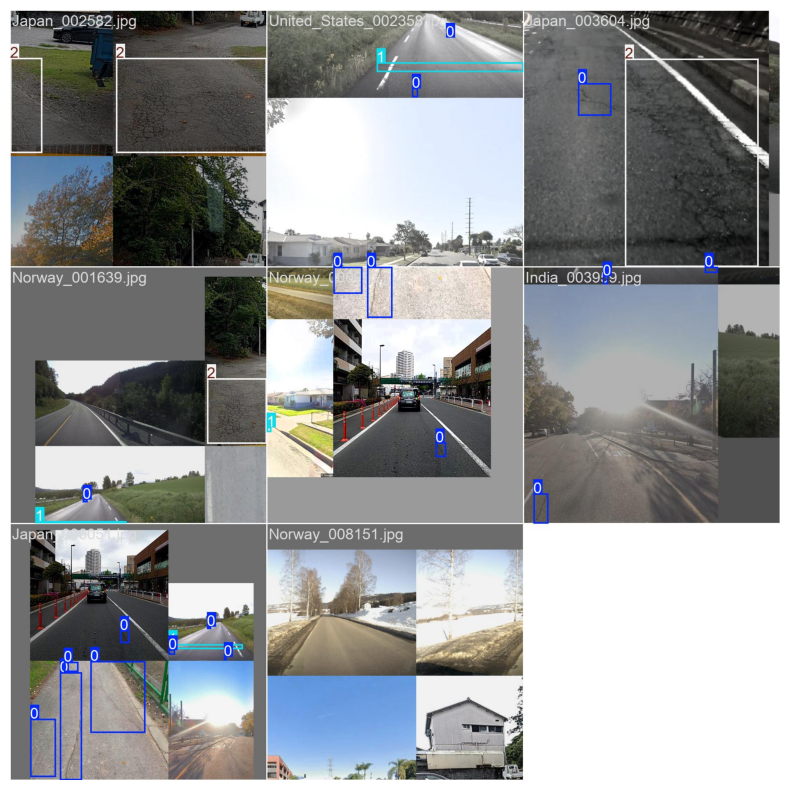

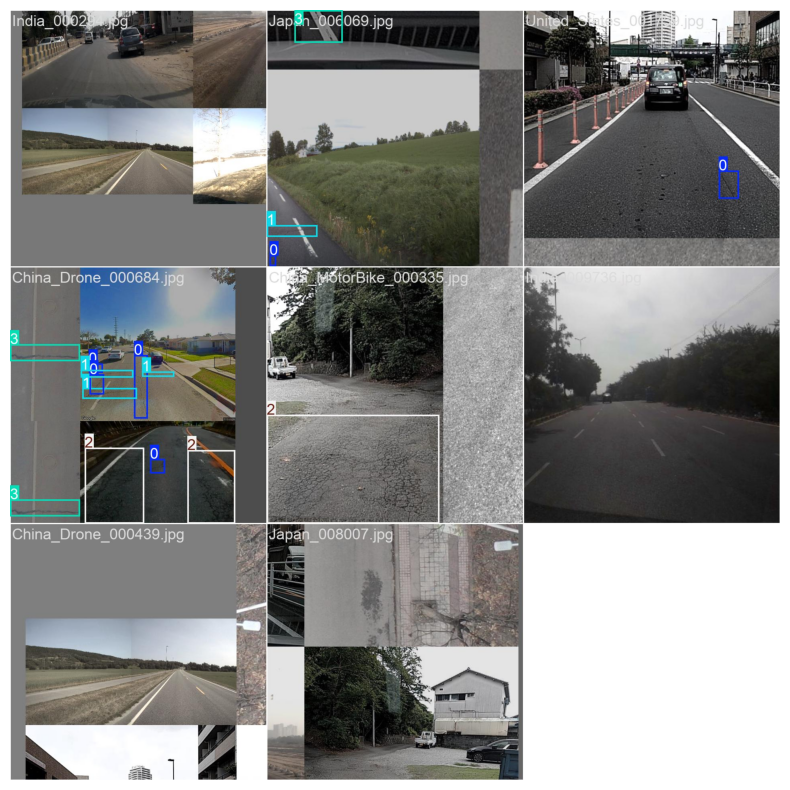

In [16]:
train_batch0 = Image.open(RUN_DIR / "train_batch0.jpg")
train_batch1 = Image.open(RUN_DIR / "train_batch1.jpg")
train_batch2 = Image.open(RUN_DIR / "train_batch2.jpg")

plt.figure(figsize=(16,10))
plt.imshow(train_batch0)
plt.axis("off")
plt.show()

plt.figure(figsize=(16,10))
plt.imshow(train_batch1)
plt.axis("off")
plt.show()

plt.figure(figsize=(16,10))
plt.imshow(train_batch2)
plt.axis("off")
plt.show()

### Observation

The sampled training batches illustrate the images and annotations used during training. These visualizations confirm that bounding boxes and class labels were correctly interpreted by the training pipeline before model optimization.

# Evaluation Summary

The baseline YOLO11 Nano model successfully completed evaluation on the RoadVision development dataset.

## Key Findings

- Successfully loaded and evaluated the trained baseline model.
- Training losses demonstrated overall convergence throughout the experiment.
- Detection metrics improved consistently across training epochs.
- Generated evaluation artifacts validated both dataset integrity and training behavior.
- The baseline model establishes a reliable reference for future performance comparisons.

# Final Summary

The evaluation confirms that the RoadVision baseline model was successfully trained and produces meaningful road damage detections on the development dataset.

The generated performance metrics, visual artifacts, and training analyses provide a comprehensive assessment of the baseline model and establish a strong foundation for subsequent inference, application integration, and production-scale training.